# 3 压力与升力分析

本 Notebook 对应项目二任务 2.2 与 3.2，目标是：

1. 计算圆柱表面压力系数 $C_p(\theta)$。
2. 通过数值积分计算升力并对比理论值 $L'=\rho U\Gamma$。
3. 统计误差并可视化 $\Gamma-L'$ 关系。

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

root = Path.cwd()
if not (root / 'src').exists():
    for p in [root, *root.parents]:
        if (p / 'src').exists() and (p / 'requirements.txt').exists():
            root = p
            break
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from src.core.pressure import (
    cylinder_surface_pressure,
    integrate_lift_from_cp,
    lift_theory_kj,
    scan_gamma_lift,
 )
from src.visualization.plot_pressure import plot_surface_cp, plot_gamma_lift_curve

U = 1.0
a = 1.0
rho = 1.225
gamma = 5.0

surface = cylinder_surface_pressure(U=U, a=a, gamma=gamma, rho=rho, n_points=1000)
lift_num = integrate_lift_from_cp(surface['theta'], surface['cp'], U=U, a=a, rho=rho)
lift_theory = lift_theory_kj(rho=rho, U=U, gamma=gamma)
eps = abs(lift_num / lift_theory - 1.0)

print({'lift_num': lift_num, 'lift_theory': lift_theory, 'relative_error': eps})

{'lift_num': 6.125000000000002, 'lift_theory': 6.125, 'relative_error': 2.220446049250313e-16}


## Gamma-Lift 线性验证

下面对 $\Gamma\in[-4\pi Ua, 4\pi Ua]$ 扫描，并对比数值积分与库塔-茹科夫斯基理论结果。

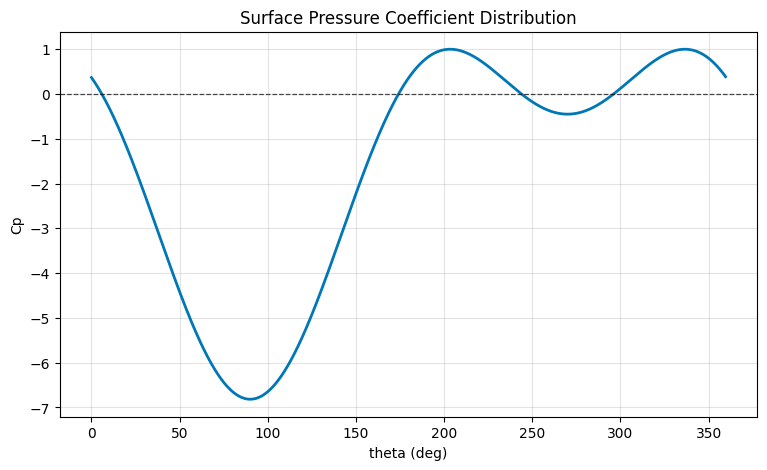

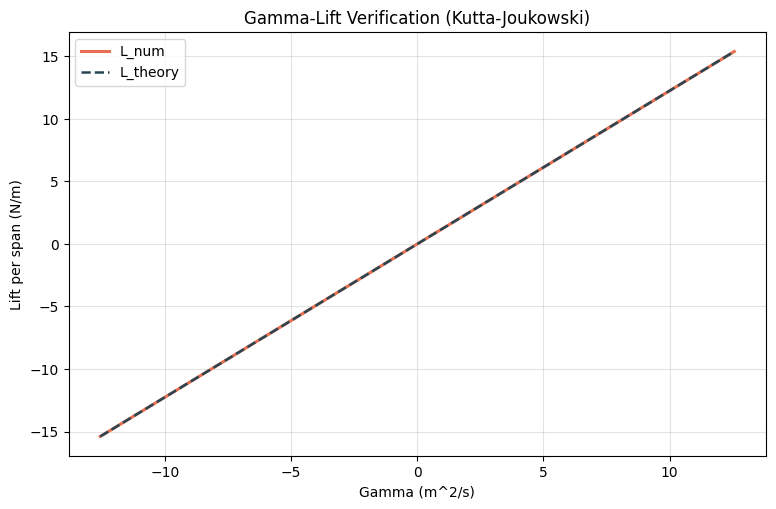

saved: /Users/fancy2/work/code/fubianhanshu/flow_project2/reports/figures/stage2_surface_cp.png
saved: /Users/fancy2/work/code/fubianhanshu/flow_project2/reports/figures/stage3_gamma_lift_notebook.png
max_relative_error = 1.1102230246251565e-15


,gamma,lift_num,lift_theory,relative_error
0,-12.566371,-15.393804,-15.393804,0.000000e+00
1,-12.147492,-14.880677,-14.880677,0.000000e+00
2,-11.728613,-14.367550,-14.367550,1.110223e-16
3,-11.309734,-13.854424,-13.854424,2.220446e-16
4,-10.890855,-13.341297,-13.341297,0.000000e+00


In [3]:
gamma_values = np.linspace(-4*np.pi*U*a, 4*np.pi*U*a, 61)
df = scan_gamma_lift(U=U, a=a, rho=rho, gamma_values=gamma_values, n_points=1500)

fig_dir = root / 'reports' / 'figures'
fig_dir.mkdir(parents=True, exist_ok=True)

fig1, _ = plot_surface_cp(surface['theta'], surface['cp'])
cp_fig_path = fig_dir / 'stage2_surface_cp.png'
fig1.savefig(cp_fig_path, dpi=180, bbox_inches='tight')
plt.show()

fig2, _ = plot_gamma_lift_curve(df)
gamma_fig_path = fig_dir / 'stage3_gamma_lift_notebook.png'
fig2.savefig(gamma_fig_path, dpi=180, bbox_inches='tight')
plt.show()

print('saved:', cp_fig_path)
print('saved:', gamma_fig_path)
print('max_relative_error =', float(np.nanmax(df['relative_error'].to_numpy())))
df.head()